## Yelp Review Sentiment Analysis -- Modeling

This notebook build and evaluates NLP classification models to predict sentiment analysis (positive/negative) from Yelp reviews. We compare Logistic Regresion (baseline model), Naive Bayes, and SVM using TF-IDF features, followed by keyword analysis, word clouds, and an attempted topic modeling investigation using LDA.

Dataset: 197,667 preprocessed Yelp reviews

Task: Binary sentiment classification (1-2 stars = negative, 4-5 stars = positive)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.decomposition import LatentDirichletAllocation

## Loading Data & EDA


In [2]:
df = pd.read_parquet('../data/ratings_clean.parquet')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197667 entries, 0 to 197666
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   review_id         197667 non-null  str  
 1   review_rating     197667 non-null  int64
 2   review_processed  197667 non-null  str  
 3   review_length     197667 non-null  int64
 4   review_clean      197667 non-null  str  
dtypes: int64(2), str(3)
memory usage: 173.2 MB


In [4]:
df.describe()

,review_rating,review_length
count,197667.000000,197667.000000
mean,3.770629,99.495616
std,1.461044,82.312755
min,1.000000,10.000000
25%,3.000000,41.000000
50%,4.000000,74.000000
75%,5.000000,131.000000
max,5.000000,500.000000


In [5]:
df.head()

,review_id,review_rating,review_processed,review_length,review_clean
0,nyTyg_9bjchXgdVINGj3MA,2,pizza good not good giordanos eaten service fa...,42,pizza was good not as good as the other giorda...
1,now6TBOX13QTyNuEzdRs-A,5,love love love mesa produce favorite abby work...,78,i love love love mesa produce and its my favor...
2,I0LSYmJ24VMFp5r4iSWkJg,5,obsessed buffalo wing garlic buffalo wing amaz...,66,i am obsessed with the buffalo wings here the ...
3,aSS1Ih4sin_6Xc5MvrSYrQ,2,priced salted 12each plus convenience fee fami...,92,over priced and over salted at 12each plus a c...
4,GE0x42C3onsXCV44f7emxw,4,best neighbor ever no complaint yet oh actuall...,35,best neighbors ever no complaints yet oh they ...


## Data Filtering

In [6]:
df= df[df['review_rating']!=3]

Removing the reviews that are a 3 because I want to perform a binary classiciation at first. The issue with 3-starred reviews is they can be ambigious whether or not they are positive or negative. For the purposes of this classification I am going to remove them.

In [7]:
df['review_rating'].value_counts()

review_rating
5    91691
4    41938
1    28821
2    15350
Name: count, dtype: int64

Ensuring the 3 starred reviews were properly removed.


In [8]:
df['sentiment']= (df['review_rating']>=4).astype(int)
df.head()

,review_id,review_rating,review_processed,review_length,review_clean,sentiment
0,nyTyg_9bjchXgdVINGj3MA,2,pizza good not good giordanos eaten service fa...,42,pizza was good not as good as the other giorda...,0
1,now6TBOX13QTyNuEzdRs-A,5,love love love mesa produce favorite abby work...,78,i love love love mesa produce and its my favor...,1
2,I0LSYmJ24VMFp5r4iSWkJg,5,obsessed buffalo wing garlic buffalo wing amaz...,66,i am obsessed with the buffalo wings here the ...,1
3,aSS1Ih4sin_6Xc5MvrSYrQ,2,priced salted 12each plus convenience fee fami...,92,over priced and over salted at 12each plus a c...,0
4,GE0x42C3onsXCV44f7emxw,4,best neighbor ever no complaint yet oh actuall...,35,best neighbors ever no complaints yet oh they ...,1


Making my predictor feature either 1 (positive review) or 0 (negative review).

In [9]:
df['sentiment'].value_counts(normalize=True)

sentiment
1    0.751569
0    0.248431
Name: proportion, dtype: float64

 As we can see, there is a heavy imbalance in my predictor variable. This is important to note when performing the Logistic Regression because it might bias the results. In order to prevent this I need to remember to put class_weight = balanced in the function call for the Logistic Regression.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df['review_processed'], df['sentiment'], test_size=.2, random_state=42, stratify=df['sentiment'] )


Make my train and test data for my data and the predictor variables. My test size is 20% of the data and my train data is the remainder (80%). I used stratify on the predictor column because I want to preserve the 3:1 ratio of positive to negative reviews in my train and test data.

In [11]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
x_train_tfidf = tfidf.fit_transform(X_train)
x_test_tfidf = tfidf.transform(X_test)



Making my vectorizor to give numerical values to certain words and fitting it to my training data.


In [12]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [13]:
y_pred =  model.predict(x_test_tfidf)
print(classification_report(y_test, y_pred, target_names= ['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.88      0.95      0.91      8834
    Positive       0.98      0.96      0.97     26726

    accuracy                           0.95     35560
   macro avg       0.93      0.95      0.94     35560
weighted avg       0.96      0.95      0.96     35560



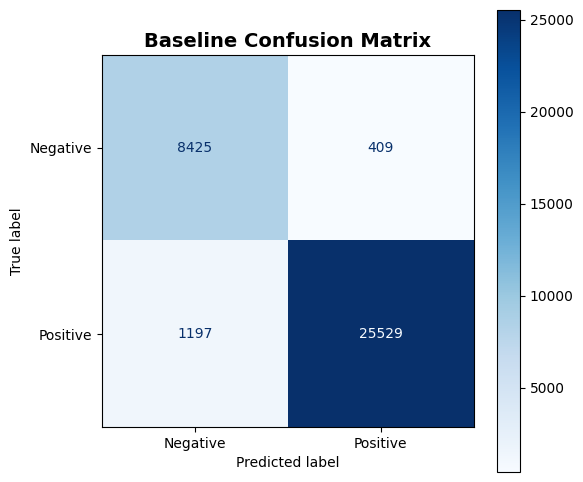

In [14]:
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Baseline Confusion Matrix', fontweight='bold', fontsize=14)

plt.savefig('../outputs/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()



As we can see the model performed outstandingly well. In the classification report we can observe that the model had an issue false positives. While there were about 1/3 less FP than FN, since our dataset was imbalances, the proportion of FP was higher than that of the FN. This caused our precision for negatives to be comparatively worse than the positives. This could be due to the class imbalances we observed earlier in the EDA portion of this investigation. The model might have overcorrected for the class imbalances, causing the lower precision score for negatives. The .95 recall score for negatives indicates that the model correctly identified 95% of all actual negative reviews, missing only 5% of them as FN. While there are still some areas that need improvement (FP), this is a great baseline model.

In [15]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = pd.Series(coefficients, index= feature_names).nlargest(20)
top_negative = pd.Series(coefficients, index = feature_names).nsmallest(20)

print("Top words predicting POSITIVE:")
print(top_positive)
print("\nTop words predicting NEGATIVE:")
print(top_negative)

Top words predicting POSITIVE:
great               12.971280
delicious           12.815120
amazing             12.518710
perfect              9.104582
best                 9.050271
awesome              8.661902
excellent            8.550518
fantastic            8.093337
love                 7.698627
definitely           7.558243
good                 6.990163
wonderful            6.984293
favorite             6.974190
loved                6.615592
friendly             6.387224
helpful              6.337944
thank                6.264247
perfectly            5.876504
yummy                5.839909
not disappointed     5.813802
dtype: float64

Top words predicting NEGATIVE:
worst            -11.169590
not               -9.859821
bland             -8.294420
horrible          -8.225773
disappointing     -8.130921
rude              -8.108905
terrible          -7.680180
mediocre          -7.230616
awful             -6.822725
not good          -6.632387
poor              -6.624163
not worth     

We can see from the highly positive and highly negative keywords that our model is interpreting correctly. Words like 'love', 'great', 'delicious' are all words that I would expect a 4/5 review to have. Often times in these positive reviews people are priasing the food, staff, atmosphere and using complementary words to incentivize others to try out the store, restaurant, bar, etc. On the other hand, the negative words correspond to what I would expect in a porr review. Words like 'overpriced', 'dissapointed', 'worst', or 'bland' are all words I associate with a negative review. Additionally, words like not worth or not disappointed indicate that keeping bigrams was an important choice we made earlier in the preprocessing steps. This is important because otherwise not disappointed likely would have been classified as 2 seperate negative words instead of a positive one when processed together.

In [16]:
nb_model = MultinomialNB()

nb_model.fit(x_train_tfidf, y_train)
y_pred_nb = nb_model.predict(x_test_tfidf)

print('Naive Bayes:')
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.90      0.81      0.85      8834
    Positive       0.94      0.97      0.95     26726

    accuracy                           0.93     35560
   macro avg       0.92      0.89      0.90     35560
weighted avg       0.93      0.93      0.93     35560



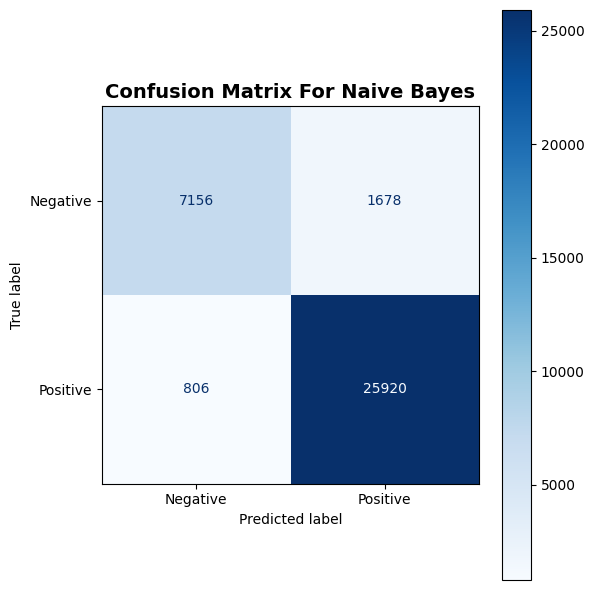

In [17]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
display = ConfusionMatrixDisplay(cm_nb, display_labels = ['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6,6))
display.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix For Naive Bayes", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

The Naive Bayes (NB) model performed worse than our baseline Logistic Regression model as seen by both the confusion matrix and the classification report. While the precision value for negative reviews slightly incresae (by .02 or 2%), the recall for both negative values took a big hit. This means more true negatives were missed and incorrectly labeled as positive (FN) One reasoning for this is that Naive Bayes treats every word as independent which isn't true in linguistics. For example a phrase like 'the food was not good' might miss that the word food might be slightly associated with a positive-leaning review. Addiitonally, it may not understand that 'not good' when put together has a seperate meaning from 'not' and 'good'  This may have lead to a misclassification especially in cases where not disappointed may have been treated as a negative phrase when in reality it often indicates a more positive leaning or moderate review.

In [18]:
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter =2000)
svm_model.fit(x_train_tfidf, y_train)
y_pred_svm=svm_model.predict(x_test_tfidf)

print("SVM:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))



SVM:
              precision    recall  f1-score   support

    Negative       0.89      0.95      0.92      8834
    Positive       0.98      0.96      0.97     26726

    accuracy                           0.96     35560
   macro avg       0.94      0.95      0.94     35560
weighted avg       0.96      0.96      0.96     35560



/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_95540/3142051215.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


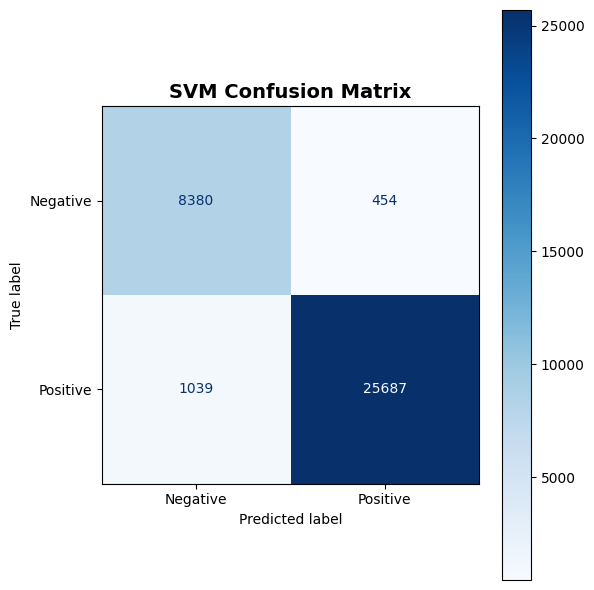

In [19]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
display_svm = ConfusionMatrixDisplay(cm_svm, display_labels = ['Negative', 'Positive'])

fig, ax = plt.subplots(figsize= (6,6))
display_svm.plot(ax=ax, cmap='Blues')
plt.title('SVM Confusion Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
fig.show()

As shown my the confusion matrix and the classification report, SVM performed the best out of the previous 2 models. It slightly outcompeted the baseline Logistic Regression model in the negative review's recall. SVM is often better at generalizing high-dimensional text data when compared to the baseline model, which is likely why is slightly outperformed the Logistic Regression. It correctly identified more True Positives while there was a slight increase in False Positives from the baseline model, the increase of TP resulted in the SVM outcompeting the other model. The biggest change I observed in this model was the ratio of TP to FN. The changes observed were  improvements on the positive class as the model predicted roighly 10% less FN compared to the baseline. This indicates that the remaining errors are likely ambigious reviews.

In [20]:
results = pd.DataFrame(
    {
        'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
        'Negative F1': [
            f1_score(y_test, y_pred, pos_label=0),
            f1_score(y_test, y_pred_nb, pos_label=0),
            f1_score(y_test, y_pred_svm, pos_label=0)
        ],
        'Positive F1': [
            f1_score(y_test, y_pred, pos_label=1),
            f1_score(y_test, y_pred_nb, pos_label=1),
            f1_score(y_test, y_pred_svm, pos_label=1)
        ],
        'Weighted F1': [
            f1_score(y_test, y_pred, average='weighted'),
            f1_score(y_test, y_pred_nb, average='weighted'),
            f1_score(y_test, y_pred_svm, average='weighted')
    ]
    }
)

print(results.to_string(index=False))

              Model  Negative F1  Positive F1  Weighted F1
Logistic Regression     0.912982     0.969505     0.955463
        Naive Bayes     0.852108     0.954274     0.928894
                SVM     0.918205     0.971759     0.958455


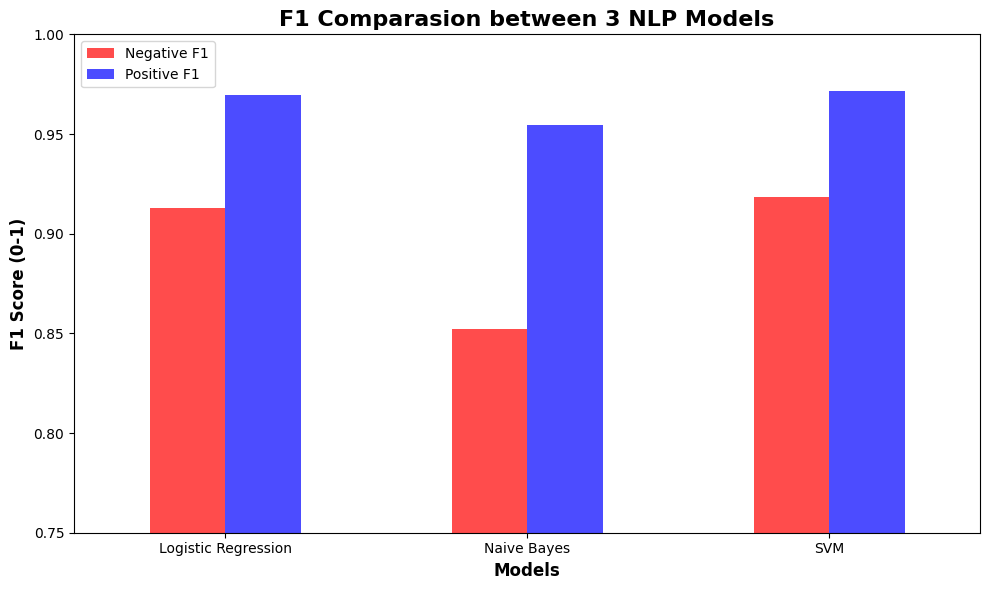

In [21]:
results.set_index('Model')[['Negative F1', 'Positive F1']].plot(
    kind='bar', figsize=(10,6), color=['red', 'blue'], alpha=.7
)

plt.title('F1 Comparasion between 3 NLP Models', fontweight='bold', fontsize=16)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('F1 Score (0-1)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(.75,1)
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

SVM was selected as the best performing model, achieving a Negative F1 of 0.918 and Weighted F1 of 0.958, outperforming both Logistic Regression and Naive Bayes across all metrics. The narrow gap between SVM and Logistic Regression suggests both models are approaching the performance ceiling for TF-IDF based classification, pointing toward transformer-based models as the natural next step for further improvement.

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', LinearSVC(class_weight='balanced', random_state=42))
])

param_grid= {
    'tfidf__max_features': [5000, 10000, 20000, 50000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1,5],
    'svm__C': [.1, 1, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid, 
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='f1_weighted'
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'svm__C': 1, 'tfidf__max_features': 50000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.961724


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'svm__C': 1, 'tfidf__max_features': 50000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.961724

In [ ]:
tfidf_optimized=TfidfVectorizer(max_features=50000, min_df = 1, ngram_range= (1,2))
X_train_tfidf_optimized = tfidf_optimized.fit_transform(X_train)
X_test_tfidf_optimized = tfidf_optimized.transform(X_test)

svm_optimized = LinearSVC(C=1, class_weight='balanced', random_state=42, max_iter=2000)
svm_optimized.fit(X_train_tfidf_optimized, y_train)
y_pred_svm_optimized = svm_optimized.predict(X_test_tfidf_optimized)
print(classification_report(y_test, y_pred_svm_optimized, target_names=['Negative', 'Positive']))

joblib.

              precision    recall  f1-score   support

    Negative       0.91      0.94      0.93      8834
    Positive       0.98      0.97      0.97     26726

    accuracy                           0.96     35560
   macro avg       0.95      0.96      0.95     35560
weighted avg       0.96      0.96      0.96     35560



/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_95540/4158503261.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


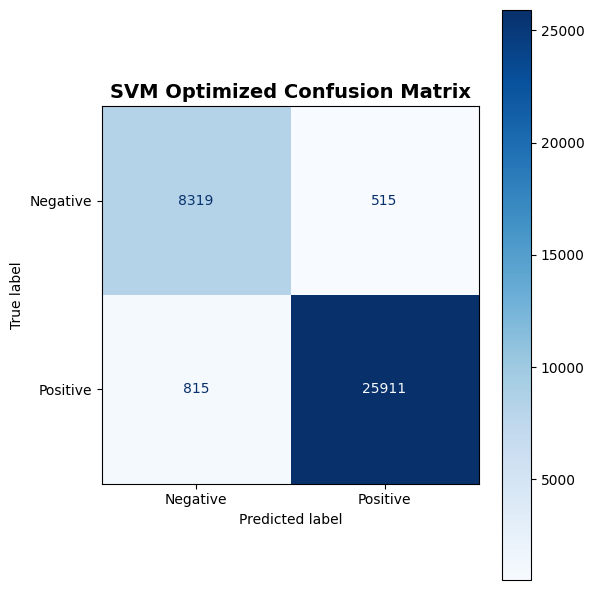

In [34]:
cm_svm = confusion_matrix(y_test, y_pred_svm_optimized)
display_svm = ConfusionMatrixDisplay(cm_svm, display_labels = ['Negative', 'Positive'])

fig, ax = plt.subplots(figsize= (6,6))
display_svm.plot(ax=ax, cmap='Blues')
plt.title('SVM Optimized Confusion Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_svm_optimized.png', dpi=150, bbox_inches='tight')
fig.show()

Hyperparameter tuning vai increasing max_features from 10,000 to 50,000 yielded a modest but consistent improvement on the negative class. Precision improved by 2% (89%-91%), reflecting the model's ability to leverage a richer vocabulary to make more accurate negative predictions. The marginal recall decrease of 1 point represents an acceptable tradeoff, resulting in a new F1 improvement of .01 for the negative class. The positive class remiained unchanged, indicating the baseline SVm was optimal for that class.

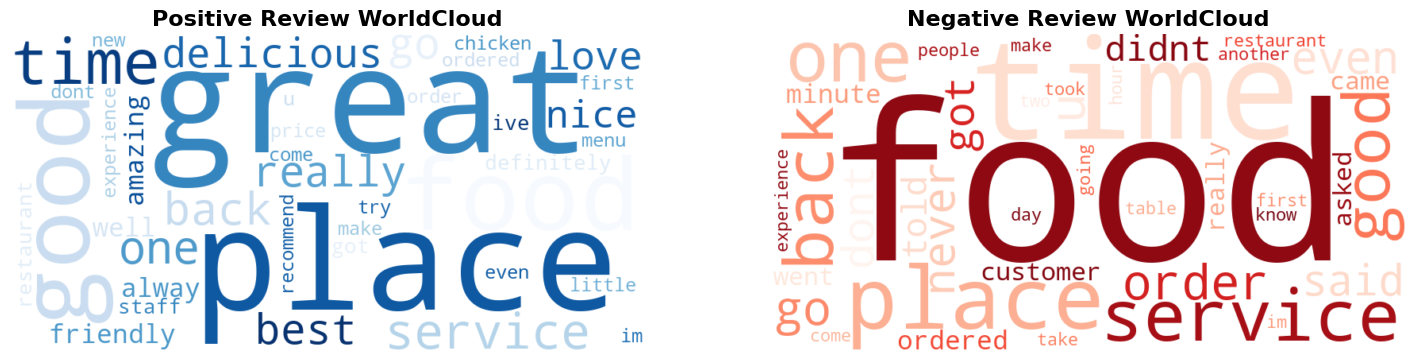

In [23]:
positive_reviews= ' '.join(df[df['sentiment']==1]['review_processed'])
negative_reviews=' '.join(df[df['sentiment']==0]['review_processed'])

fig, axes = plt.subplots(1, 2, figsize=(18,8))


wc_positive = WordCloud(width=800, height=400, background_color='white', max_words=40, colormap= 'Blues', collocations=False).generate(positive_reviews)
wc_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=40, collocations=False).generate(negative_reviews)

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].set_title('Positive Review WorldCloud', fontweight='bold', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].set_title('Negative Review WorldCloud', fontweight='bold', fontsize=16)
axes[1].axis('off')

plt.savefig('../outputs/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

The word clouds between the positive and negative reviews are oddly similar. While there are stark differences like "love" or "amazing" in the positive review cloud, there are a lot of similar words that both clouds share. For example, "food", "restaurant", and "still" were shared between both of the clouds. I guess I was expecting there to be more of a difference between the two clouds, but this is only counting word frequency, not the weight of each word. I see more weighted words in the positive cloud like "love", "amazing", "awesome", and "delicious" compared to "left" in the negative cloud. There are many more nouns in the negative review cloud as opposed to there being more adjectives/verbs in the positive review cloud. This may signal that people are more likely to gush or go into depth about their feeling and experience in a positive review as opposed to a negative review where they may be stating the facts of what caused their experience to be negative.

In [24]:
cv = CountVectorizer(max_features=5000, max_df=.95, min_df=50, ngram_range=(1,1))
dtm = cv.fit_transform(df['review_processed'])

In [25]:
lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=50, learning_method='batch')
lda.fit(dtm)


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",50
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [26]:
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f'Topic {topic_idx+1}: {", ".join(top_words)}')

Topic 1: creepy, conveniently, food option, beforehand, fast friendly, cupcake, food okay, came, egg benedict, beef
Topic 2: cupcake, indianapolis, grandmother, genuinely, heaven, clothing, appetite, could ever, adorable, admit
Topic 3: conveniently, fast friendly, grandmother, creepy, gladly, humor, figure, indianapolis, backed, grandma
Topic 4: fast friendly, fantastic food, coworkers, indianapolis, light fluffy, felt, causing, amazing got, grandmother, good especially
Topic 5: cupcake, food option, conveniently, creepy, family dinner, andor, could ever, anything else, heaven, enjoyed experience


LDA topic modeling was attempted on the sampled dataset. Despite multiple iterations adjusting the CountVectorized params and increasing the number of LDA iterations, the model failed to produce interpretable topics. The primary issue was the processed text contained multi-word phrases baked in as tokens from the earlier preprocessing steps, which polluted the topic word distrubutions and prevented clean thematic separation.

A path forward would be to rebuild the preprocessing pipeline specifically for LDA, using unigrams only, removing domain-specific noise words, and icnreasing the number of LDA itertions to allow proper convergence. Alternatively, more modern topic modeling approaches such as BERTopic, which leverages transformer embeddings rather than word counts, would likely produce more coherent and interpretable topics on this type of review data.

## Conclusion

This investigation successfully built a sentiment classification pipeline on Yelp review data. SVM achieved the strongest performance with a weighted F1 score of .958, edging out Logistic Regression (.955) and significantly outperforming Naive Bayes (.929). Feature weight analysis confirmed the models learned meaningful linguistic patterns, with negation bigrams like 'not good' and 'not worth' correctly identified as negative signals. Additionally, feature investigation primarily through world cloud analysis revealed stark differences between positive and negative reviews. Positive reviews appear to use more descriptive words that invoke strong positive emoitions while negative reviews often utilize more nouns (recounting negative experiences, stating the facts not focusing on the emotions felt).

LDA topic modeling produced uninterpretable results due to multi-word phrases baked into the preprocessed text. Future work would involve rebuilding the preprocessing pipeline or using BERTopic for more robust topic discovery. 

In [ ]:
import joblib

joblib.dump(svm_optimized, '../outputs/svm_model.joblib')
joblib.dump(tfidf_optimized, '../outputs/tfidf_vectorizer.joblib')


plt.savefig()

TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

<Figure size 640x480 with 0 Axes>